# 1. Doing visualization on travel_data.csv(no. of samples is low because it is just for the testing purposes of the product idea)

  Destination  Visitors  Avg_Cost
0         Goa    500000     15000
1      Manali    350000     12000
2      Jaipur    400000     10000
3      Kerala    600000     18000
4      Ladakh    200000     25000
5      Shimla    300000     14000
6  Darjeeling    250000     16000
7        Agra    450000     11000
8        Ooty    280000     13000
9      Mysore    320000      9000


C:\Users\Asus\AppData\Local\Temp\ipykernel_13304\1236050459.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Destination", y="Visitors", data=df.sort_values("Visitors", ascending=False)[:10], palette="viridis")


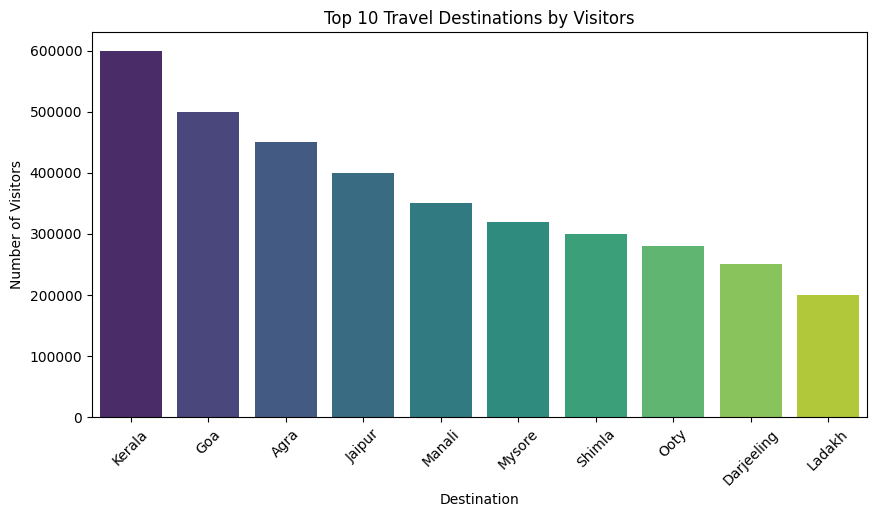

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("travel_data.csv")
print(df)

# Visualizing through Bar plot of top travel destinations
plt.figure(figsize=(10, 5))
sns.barplot(x="Destination", y="Visitors", data=df.sort_values("Visitors", ascending=False)[:10], palette="viridis")
plt.xticks(rotation=45)
plt.title("Top 10 Travel Destinations by Visitors")
plt.xlabel("Destination")
plt.ylabel("Number of Visitors")
plt.show()


# 2. Doing EDA

Missing values:
 Destination    0
Visitors       0
Avg_Cost       0
dtype: int64
            Visitors      Avg_Cost
count      10.000000     10.000000
mean   365000.000000  14300.000000
std    122949.854277   4667.856991
min    200000.000000   9000.000000
25%    285000.000000  11250.000000
50%    335000.000000  13500.000000
75%    437500.000000  15750.000000
max    600000.000000  25000.000000


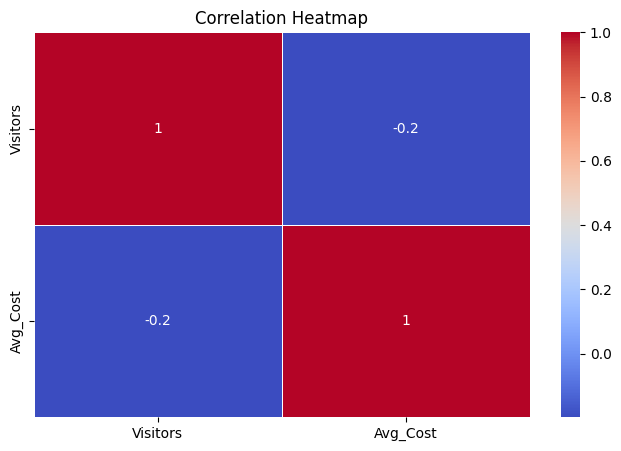

In [20]:
# Load the dataset
df = pd.read_csv("travel_data.csv")

# Checking for missing values
print("Missing values:\n", df.isnull().sum())

# Summary statistics (excluding non-numeric columns)
print(df.describe())

# Convert categorical columns to numeric if needed (One-Hot Encoding or Label Encoding)
df_numeric = df.select_dtypes(include=['number'])  # Exclude categorical columns

# Heatmap of correlations (only for numeric data)
plt.figure(figsize=(8, 5))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


# 3. Applying KNN on travel_preferences.csv(small-scale self generated dataset) that's why it is affecting the accuracy of the model.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("travel_preferences.csv")

# Group destinations into broader categories because of small scale dataset
destination_map = {
    "Goa": "Beach", "Kerala": "Beach", "Ooty": "Beach",
    "Manali": "Mountains", "Ladakh": "Mountains", "Shimla": "Mountains", "Darjeeling": "Mountains",
    "Jaipur": "Historical", "Agra": "Historical", "Mysore": "Historical",
}

# Applying mapping
df["Destination_Category"] = df["Preferred_Destination"].map(destination_map)

# Removing rows where mapping failed (destination not in map)
df = df.dropna(subset=["Destination_Category"])

# Print updated distribution
print("Updated class distribution:\n", df["Destination_Category"].value_counts())

# Encoding categorical target variable
le = LabelEncoder()
df["Destination_Category"] = le.fit_transform(df["Destination_Category"])

# Defining features and target
X = df[["Budget", "Trip_Duration", "Past_Trips"]]
y = df["Destination_Category"]

# Splitting dataset into training and testing (ensure enough samples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Training KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

# Accuracy score
print("Model Accuracy:", accuracy_score(y_test, y_pred))


Updated class distribution:
 Destination_Category
Mountains     4
Beach         3
Historical    3
Name: count, dtype: int64
Model Accuracy: 0.3333333333333333
